In [2]:
#Install and import libraries
!pip install imagehash
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imagehash
from collections import defaultdict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 3.4 MB/s eta 0:00:00


In [5]:
#Download dataset
cloud_dataset_path=kagglehub.dataset_download("aditisalvi04/indoor-plant-disease-dataset")

100%|██████████| 7.79G/7.79G [01:31<00:00, 91.4MB/s]


Extracting files...


In [4]:
class_counts = {}
image_dims = []
sample_images_per_class = {}

for root, dirs, files in os.walk(cloud_dataset_path):
    if files:
        category = os.path.basename(root)
        images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            class_counts[category] = len(images)
            sample_images_per_class[category] = os.path.join(root, images[0])

            # Record dimensions of first 10 images per class
            for img_name in images[:10]:
                img_path = os.path.join(root, img_name)
                try:
                    with Image.open(img_path) as img:
                        image_dims.append(img.size) # (width, height)
                except Exception:
                    continue

NameError: name 'cloud_dataset_path' is not defined

In [3]:
categories = list(sample_images_per_class.keys())[:6]
plt.figure(figsize=(12, 6))
for idx, cat in enumerate(categories):
    plt.subplot(3, 2, idx + 1)
    img = Image.open(sample_images_per_class[cat])
    plt.imshow(img)
    plt.title(cat, fontsize=10)
    plt.axis('off')
plt.suptitle('Sample Class Inspection', fontsize=14)
plt.tight_layout()
plt.savefig('results/eda_visualizations/sample_image_grid.png', dpi=300)
plt.show()

NameError: name 'sample_images_per_class' is not defined

In [6]:
total_images = 0

for category, count in class_counts.items():
    print(f"{category:<35} : {count}")
    total_images += count

print("Total Images:          ", total_images)

Turmeric_Leaf_Necrosis              : 812
Turmeric_Blotch                     : 1904
Turmeric_Healthy                    : 1806
Turmeric_Leaf_Spot                  : 919
Turmeric_Aphid_Infestation          : 847
Money_Plant_Chlorosis               : 115
Money_Plant_Healthy                 : 2760
Money_Plant_Manganese_Toxicity      : 596
Money_Plant_Bacterial_Wilt          : 576
Rose_Black_Spot                     : 3000
Rose_Insect_Damage                  : 2812
Rose_Downy_Mildew                   : 1102
Rose_Yellow_Mosaic_Virus            : 680
Rose_Powdery_Mildew                 : 1000
Rose_Rust                           : 1000
Rose_Healthy                        : 5530
Rose_Mosaic_Virus                   : 1000
Chrysanthemum_Bacterial_Leaf_Spot   : 767
Chrysanthemum_Healthy               : 767
Chrysanthemum_Septoria_Leaf_Spot    : 767
Hibiscus_Necrosis                   : 1200
Hibiscus_Blight                     : 1200
Hibiscus_Healthy                    : 1200
Hibiscus_Scorch      

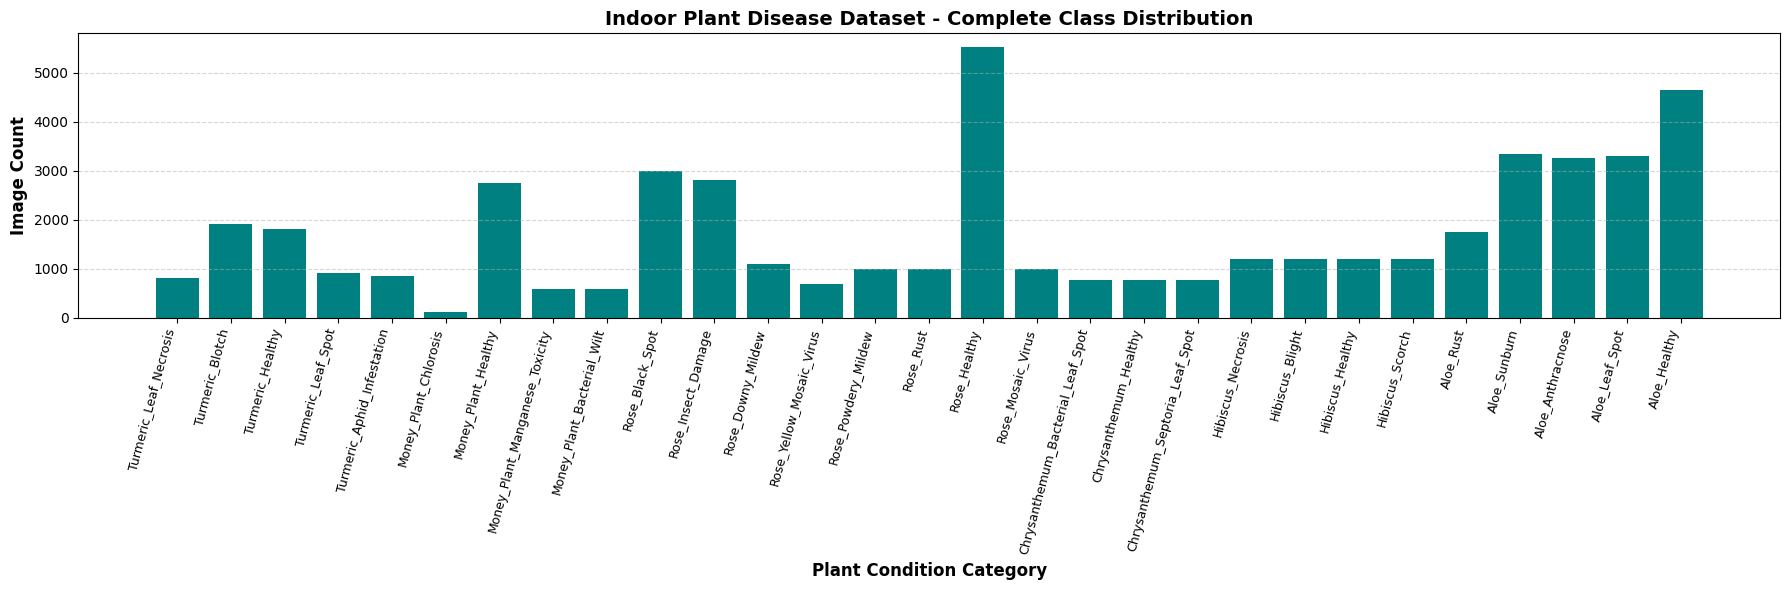

In [7]:
# Save and plot ALL dataset categories
os.makedirs('results/eda_visualizations', exist_ok=True)

plt.figure(figsize=(18, 6))  # Widened layout to fit all classes
plt.bar(list(class_counts.keys()), list(class_counts.values()), color='teal')
plt.xlabel('Plant Condition Category', fontsize=12, fontweight='bold')
plt.ylabel('Image Count', fontsize=12, fontweight='bold')
plt.title('Indoor Plant Disease Dataset - Complete Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=75, ha='right', fontsize=9)  # Steep angle so long names don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Overwrite chart in results folder
plt.savefig('results/eda_visualizations/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# **EDA**

---



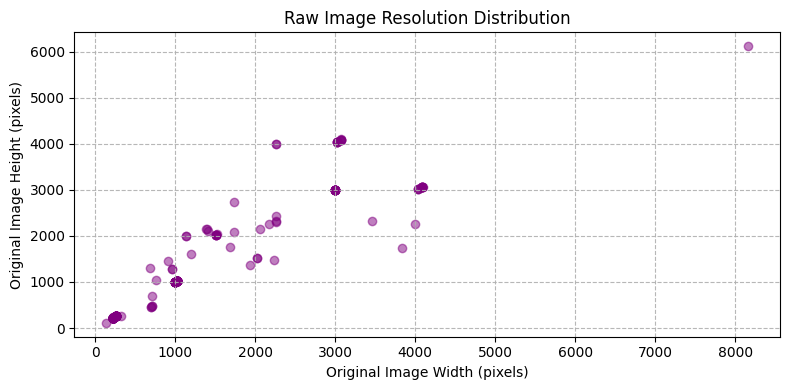

In [8]:
widths, heights = zip(*image_dims)
plt.figure(figsize=(8, 4))
plt.scatter(widths, heights, alpha=0.5, color='purple')
plt.xlabel('Original Image Width (pixels)')
plt.ylabel('Original Image Height (pixels)')
plt.title('Raw Image Resolution Distribution')
plt.grid(True, linestyle='--', alpha=0.9)
plt.tight_layout()
plt.savefig('results/eda_visualizations/resolution_distribution.png', dpi=300)
plt.show()

In [6]:
image_dims = []

for root, dirs, files in os.walk(cloud_dataset_path):
    images = [
        f for f in files
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    for img_name in images:
        img_path = os.path.join(root, img_name)
        try:
            with Image.open(img_path) as img:
                image_dims.append(img.size)
        except Exception:
            continue

print("Total images checked:", len(image_dims))
print("Dimensions:", image_dims[:10])

Total images checked: 49878
Dimensions: [(1000, 1000), (1000, 1000), (1000, 1000), (1000, 1000), (1000, 1000), (1000, 1000), (1000, 1000), (1000, 1000), (1000, 1000), (1000, 1000)]


In [ ]:
from collections import Counter

dimension_counts = Counter(image_dims)

print("\nMost common dimensions:")

for dimension, count in dimension_counts.most_common(10):
    print(dimension, ":", count)

In [10]:
import os
#Image resizing to a standed size
TARGET_SIZE = (128, 128) # (Width, Height)

resized_images = []
labels = []

print("Resizing dataset images...")

for root, dirs, files in os.walk(cloud_dataset_path):
    if files:
        category = os.path.basename(root)
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for img_name in image_files[:20]: # Sample subset per class
            img_path = os.path.join(root, img_name)
            try:
                with Image.open(img_path) as img:
                    # Convert to RGB (ensures 3 channels) and resize
                    img_resized = img.convert('RGB').resize(TARGET_SIZE, Image.Resampling.LANCZOS)

                    # Convert to numpy array
                    img_array = np.array(img_resized)

                    resized_images.append(img_array)
                    labels.append(category)
            except Exception:
                continue

# Convert list to NumPy array batch
X_resized = np.array(resized_images)
y_labels = np.array(labels)

print("\n--- RESIZING VERIFICATION ---")
print(f"Total Images Resized : {X_resized.shape[0]}")
print(f"Output Array Shape   : {X_resized.shape} (Batch Size, Height, Width, Channels)")
print(f"Single Image Resolution: {X_resized.shape[1]}x{X_resized.shape[2]} pixels")

Resizing dataset images...

--- RESIZING VERIFICATION ---
Total Images Resized : 580
Output Array Shape   : (580, 128, 128, 3) (Batch Size, Height, Width, Channels)
Single Image Resolution: 128x128 pixels


Extracting and flattening image features...
Original Feature Matrix Shape: (870, 12288) (Samples, Total Pixels)


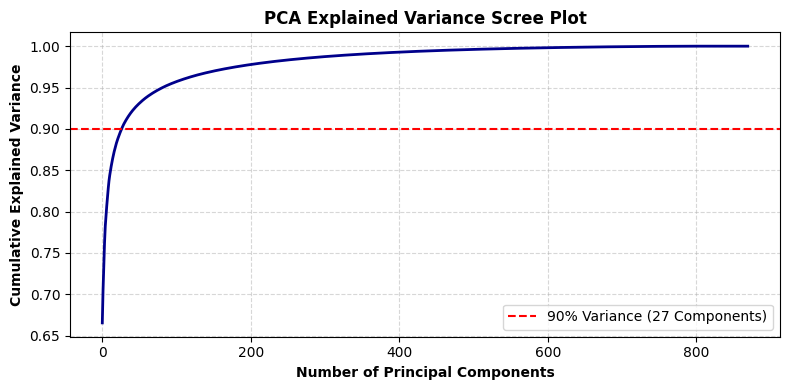

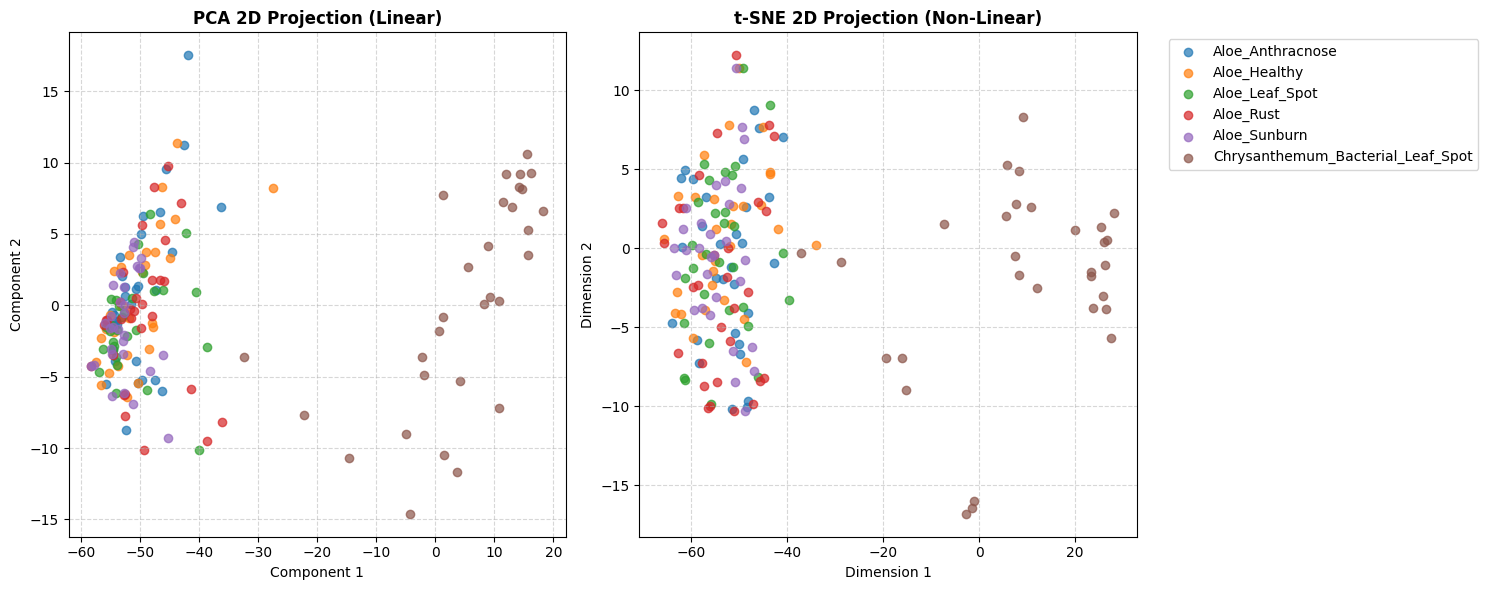


--- REDUCTION METRICS ---
Original Input Dimensions: 12288 features
Components for 90% Variance: 27 components


In [13]:
# 2. Extract and Flatten Image Data (128x128 RGB = 49,152 input features)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

IMG_SIZE = (128, 128)
X_data, y_labels = [], []

print("Extracting and flattening image features...")
for root, dirs, files in os.walk(cloud_dataset_path):
    if files:
        category = os.path.basename(root)
        images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img_name in images[:30]:  # Sample batch per class
            try:
                img_path = os.path.join(root, img_name)
                img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
                X_data.append((np.array(img) / 255.0).flatten())
                y_labels.append(category)
            except Exception:
                continue

X_data = np.array(X_data)
y_labels = np.array(y_labels)

print(f"Original Feature Matrix Shape: {X_data.shape} (Samples, Total Pixels)")

# 3. PCA Cumulative Variance Analysis
pca_full = PCA().fit(X_data)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cum_variance >= 0.90) + 1

os.makedirs('results/eda_visualizations', exist_ok=True)

# Plot Scree Plot (Cumulative Variance)
plt.figure(figsize=(8, 4))
plt.plot(cum_variance, linewidth=2, color='darkblue')
plt.axhline(y=0.90, color='r', linestyle='--', label=f'90% Variance ({n_90} Components)')
plt.xlabel('Number of Principal Components', fontweight='bold')
plt.ylabel('Cumulative Explained Variance', fontweight='bold')
plt.title('PCA Explained Variance Scree Plot', fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('results/eda_visualizations/pca_scree_plot.png', dpi=300)
plt.show()

# 4. 2D Feature Reduction (PCA vs. t-SNE)
pca_2d = PCA(n_components=2).fit_transform(X_data)
tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_data)

unique_classes = np.unique(y_labels)[:6] # Plot top 6 categories

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for cls in unique_classes:
    idx = np.where(y_labels == cls)
    axes[0].scatter(pca_2d[idx, 0], pca_2d[idx, 1], label=cls, alpha=0.7)
    axes[1].scatter(tsne_2d[idx, 0], tsne_2d[idx, 1], label=cls, alpha=0.7)

axes[0].set_title('PCA 2D Projection (Linear)', fontweight='bold')
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_title('t-SNE 2D Projection (Non-Linear)', fontweight='bold')
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('results/eda_visualizations/dimensionality_reduction_comparison.png', dpi=300)
plt.show()

print(f"\n--- REDUCTION METRICS ---")
print(f"Original Input Dimensions: {X_data.shape[1]} features")
print(f"Components for 90% Variance: {n_90} components")